In [8]:
# Get the data
import pandas as pd

df = pd.read_csv('../../../datasets/zoo.csv')
features_select = ['eggs', 'aquatic', 'venomous', 'legs', 'domestic', 'feathers', 'toothed', 'breathes', 'catsize', 'hair', 'tail', 'milk', 'backbone', 'class_type']
df = df[features_select]
df.head()

,eggs,aquatic,venomous,legs,domestic,feathers,toothed,breathes,catsize,hair,tail,milk,backbone,class_type
0,0,0,0,4,0,0,1,1,1,1,0,1,1,1
1,0,0,0,4,0,0,1,1,1,1,1,1,1,1
2,1,1,0,0,0,0,1,0,0,0,1,0,1,4
3,0,0,0,4,0,0,1,1,1,1,0,1,1,1
4,0,0,0,4,0,0,1,1,1,1,1,1,1,1


In [13]:
# Split the data


X = df.drop('class_type', axis=1)
y = df['class_type']

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# OverSamplings (SMOTE)
smote = SMOTE(random_state=42, k_neighbors=2)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f'Shape of Train {X_train.shape}, {y_train.shape}')
print(f'Shape of Test {X_test.shape}, {y_test.shape}')

Shape of Train (231, 13), (231,)
Shape of Test (21, 13), (21,)


In [ ]:
# Get the models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = [DecisionTreeClassifier(), RandomForestClassifier()]

Model: DecisionTreeClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Train Metrics: Accuracy:0.991 | F1: 0.991 | Precision: 0.992 | Recall: 0.991|
Test Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000 | 
Confusion Matriz:


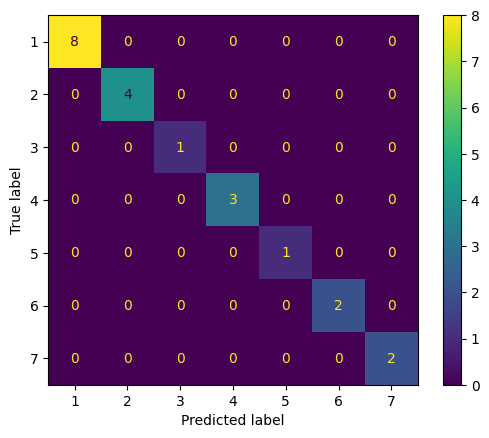

Melhores Parâmetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Melhor Score (CV F1-Macro): 0.992
Model: RandomForestClassifier
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000 | 
Confusion Matriz:


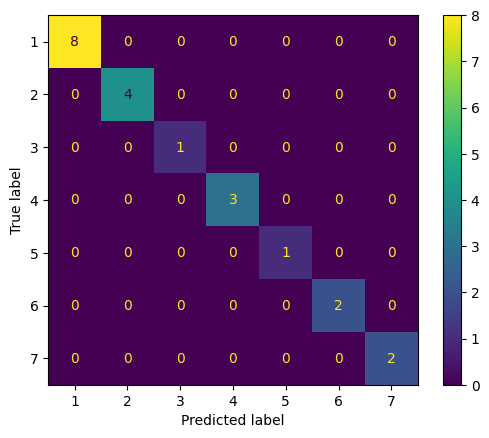

Melhores Parâmetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Melhor Score (CV F1-Macro): 0.996


In [23]:
# Train

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model in models:
    print(f'===============================================================')
    print(f"Model: {model.__class__.__name__}")

    if model.__class__.__name__ == 'DecisionTreeClassifier':
        params = {
    'max_depth': [None, 5, 10],          
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced']}
    else:
        params = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [None, 5, 10],          
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced']          
} 

    # Train
    grid = GridSearchCV(estimator=model, param_grid=params, cv = 5, n_jobs= -1, verbose=1, scoring='f1_macro')
    grid.fit(X_train, y_train)

    # Val Score
    y_preds_train = grid.predict(X_train)
    accuracy = accuracy_score(y_train, y_preds_train)
    f1 = f1_score(y_train, y_preds_train, average = 'macro')
    precision = precision_score(y_train, y_preds_train, average = 'macro')
    recall = recall_score(y_train, y_preds_train, average = 'macro')
    print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
    y_preds_test = grid.predict(X_test)
    accuracy = accuracy_score(y_test, y_preds_test)
    f1 = f1_score(y_test, y_preds_test, average = 'macro')
    precision = precision_score(y_test, y_preds_test, average = 'macro')
    recall = recall_score(y_test, y_preds_test, average = 'macro')
    confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
    print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
    plt.show()

    print(f"Melhores Parâmetros: {grid.best_params_}")
    print(f"Melhor Score (CV F1-Macro): {grid.best_score_:.3f}")
